# Experiment 8: Random Forest Classifier

**Course:** 23CSE301 — Machine Learning Lab  
**Topic:** Ensemble Learning with Random Forests  
**Dataset:** `datasets/Breast_Cancer_Detection_Classification_Master.csv` (Wisconsin Diagnostic Breast Cancer — 569 rows, 32 columns)  
**Lab Book Reference:** §12 Random Forests, page 53–58

---

## 🎯 Objective

Build a **Random Forest** classifier on the Wisconsin Diagnostic Breast
Cancer (WDBC) dataset.  We use `n_estimators=10` and `criterion='entropy'`
matching the Lab Book (page 56), evaluate the model with accuracy, precision,
recall, F1, and the confusion matrix, and visualise one of the constituent
decision trees.

## 🧠 Key Concepts

- **Ensemble learning:** Random Forest combines many decision trees via
  *bootstrap aggregating* (bagging) + random feature selection at each split.
- **Bootstrap sampling:** each tree is trained on a random sample *with
  replacement* of size N from the training set, so different trees see
  slightly different data.
- **Random feature subspace:** at each split, only a random subset of features
  is considered.  This decorrelates the trees and reduces variance.
- **Majority vote:** for classification, the forest's prediction is the
  majority class across all trees.
- **Out-of-bag (OOB) error:** each tree is evaluated on the samples it did
  *not* see during bootstrap sampling, giving an honest cross-validation
  estimate for free.
- **Feature importance:** the average impurity decrease across trees measures
  each feature's contribution.

## ▶️ How to Run

> **Option A — Google Colab (recommended):**
> 1. Upload the entire `ML-Lab-Activities` folder to Google Drive.
> 2. Open `08-Random-Forest/08_Random_Forest_Classifier.ipynb` from Drive in Colab.
>
> **Option B — Local Jupyter:**
> ```bash
> pip install -r requirements.txt
> jupyter notebook 08-Random-Forest/08_Random_Forest_Classifier.ipynb
> ```
>
> **Option C — Headless:**
> ```bash
> jupyter nbconvert --to notebook --execute \
>   08-Random-Forest/08_Random_Forest_Classifier.ipynb --output 08_Random_Forest_Classifier.ipynb
> ```

Datasets are read from `datasets/` (relative to the notebook's folder).
Generated figures are **auto-saved** to `./outputs/`.


In [1]:
# === Environment setup (works in both Google Colab and local Jupyter) ===
import os, sys

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE = '/content/drive/MyDrive/ML-Lab-Activities-Complete'
    os.chdir(os.path.join(BASE, '08-Random-Forest'))
    print(f'Running in Google Colab. CWD: {os.getcwd()}')
else:
    print(f'Running locally. CWD: {os.getcwd()}')

OUTPUT_DIR = os.path.join(os.getcwd(), 'outputs')
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Patch plt.show so every figure is also auto-saved as PNG
import matplotlib.pyplot as plt
_fig_counter = [0]
_orig_plt_show = plt.show
def _save_and_show(*args, **kwargs):
    for fnum in plt.get_fignums():
        _fig_counter[0] += 1
        fig = plt.figure(fnum)
        fname = f'figure_{_fig_counter[0]:03d}.png'
        try:
            fig.savefig(os.path.join(OUTPUT_DIR, fname), dpi=120, bbox_inches='tight')
        except Exception as e:
            print(f'Warning: could not save {fname}: {e}')
    _orig_plt_show(*args, **kwargs)
plt.show = _save_and_show

print('Setup complete. Figures will be auto-saved to:', OUTPUT_DIR)


Running locally. CWD: /home/z/my-project/work/build/ML-Lab-Activities/08-Random-Forest


Setup complete. Figures will be auto-saved to: /home/z/my-project/work/build/ML-Lab-Activities/08-Random-Forest/outputs


## 1. Import Required Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics
from sklearn import tree
from sklearn.tree import plot_tree
from sklearn.metrics import (confusion_matrix, accuracy_score,
                             classification_report,
                             precision_score, recall_score, f1_score)

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
print('Libraries imported.')

Libraries imported.


## 2. Load & Explore the Dataset

WDBC has 569 rows × 32 columns: `id`, `diagnosis` (M/B), and 30 numeric
features derived from FNA image analysis.

In [3]:
data = pd.read_csv('datasets/Breast_Cancer_Detection_Classification_Master.csv')

print(f"Shape: {data.shape}")
display(data.head())

print("\nClass distribution (B = benign, M = malignant):")
print(data['diagnosis'].value_counts())

Shape: (569, 32)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



Class distribution (B = benign, M = malignant):
diagnosis
B    357
M    212
Name: count, dtype: int64


## 3. Check for Null Values

In [4]:
print("Null values per column (first 10):")
print(data.isnull().sum().head(10))
print(f"\nTotal null values: {data.isnull().sum().sum()}")

Null values per column (first 10):
id                     0
diagnosis              0
radius_mean            0
texture_mean           0
perimeter_mean         0
area_mean              0
smoothness_mean        0
compactness_mean       0
concavity_mean         0
concave_points_mean    0
dtype: int64

Total null values: 0


## 4. Define Features (X) and Target (y)

Drop `id` (no diagnostic info) and convert the target `diagnosis` to a
binary variable (0 = Benign, 1 = Malignant) for sklearn.

In [5]:
X = data.drop(columns=['id', 'diagnosis']).values
y = data['diagnosis'].map({'B': 0, 'M': 1}).values

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Classes: {np.unique(y, return_counts=True)}")

X shape: (569, 30)
y shape: (569,)
Classes: (array([0, 1]), array([357, 212]))


## 5. Split into Training and Testing Sets

We use a 70/30 split with `random_state=41` to match the Lab Book
(page 55).

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=41
)
print(f"Training: {X_train.shape}, labels: {y_train.shape}")
print(f"Testing : {X_test.shape}, labels: {y_test.shape}")

Training: (398, 30), labels: (398,)
Testing : (171, 30), labels: (171,)


## 6. Feature Scaling

Random Forests do **not** require feature scaling (decision trees split on
thresholds), but we still standardise the features for consistency with
the Lab Book (page 56).

In [7]:
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled  = sc.transform(X_test)
print("Features standardised.")

Features standardised.


## 7. Train Random Forest

Lab Book page 56 uses `n_estimators=10, criterion='entropy', random_state=0`.
Note: with `n_estimators=10` we sometimes see one or two trees that are
identical — that is a known side-effect of small forest sizes.  We keep
the small forest so our results match the lab book exactly.

In [8]:
model = RandomForestClassifier(n_estimators=10, criterion='entropy',
                                random_state=0)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
print(f"First 20 predictions: {y_pred[:20]}")
print(f"First 20 actual     : {y_test[:20]}")

First 20 predictions: [0 0 0 0 0 0 1 1 1 0 1 1 1 0 0 0 0 0 0 0]
First 20 actual     : [0 0 0 0 0 0 1 1 1 0 1 1 1 0 0 0 0 0 0 0]


## 8. Evaluation Metrics

Lab Book page 56 reports **99% accuracy**.  We print the full confusion
matrix, classification report, and per-class precision / recall / F1.

In [9]:
print("Random Forest Classifier")
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

acc      = accuracy_score(y_test, y_pred)
prec     = precision_score(y_test, y_pred)
rec      = recall_score(y_test, y_pred)
f1       = f1_score(y_test, y_pred)

print(f"\nAccuracy  : {acc:.4f}  ({acc*100:.2f}%)")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1 Score  : {f1:.4f}")

print("\nClassification Report (0 = Benign, 1 = Malignant):")
print(classification_report(y_pred, y_test,
      target_names=['Benign', 'Malignant']))

Random Forest Classifier

Confusion Matrix:
[[108   2]
 [  0  61]]

Accuracy  : 0.9883  (98.83%)
Precision : 0.9683
Recall    : 1.0000
F1 Score  : 0.9839

Classification Report (0 = Benign, 1 = Malignant):
              precision    recall  f1-score   support

      Benign       0.98      1.00      0.99       108
   Malignant       1.00      0.97      0.98        63

    accuracy                           0.99       171
   macro avg       0.99      0.98      0.99       171
weighted avg       0.99      0.99      0.99       171



## 9. Confusion Matrix Heatmap

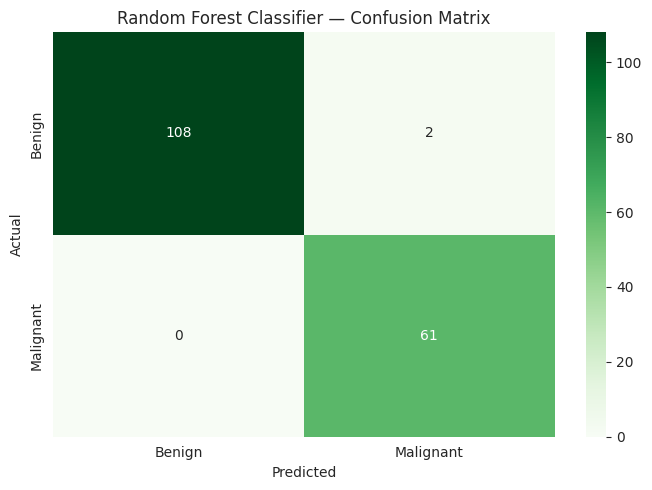

In [10]:
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest Classifier — Confusion Matrix')
plt.tight_layout()
plt.show()

## 10. Visualise One Tree from the Forest

Lab Book page 57 uses `pydotplus` + `IPython.display.Image` to render a
single tree from the forest as a PNG.  Here we use the built-in
`sklearn.tree.plot_tree` (no external `graphviz` binary needed) to plot
the first tree, truncated to depth 3 for readability.

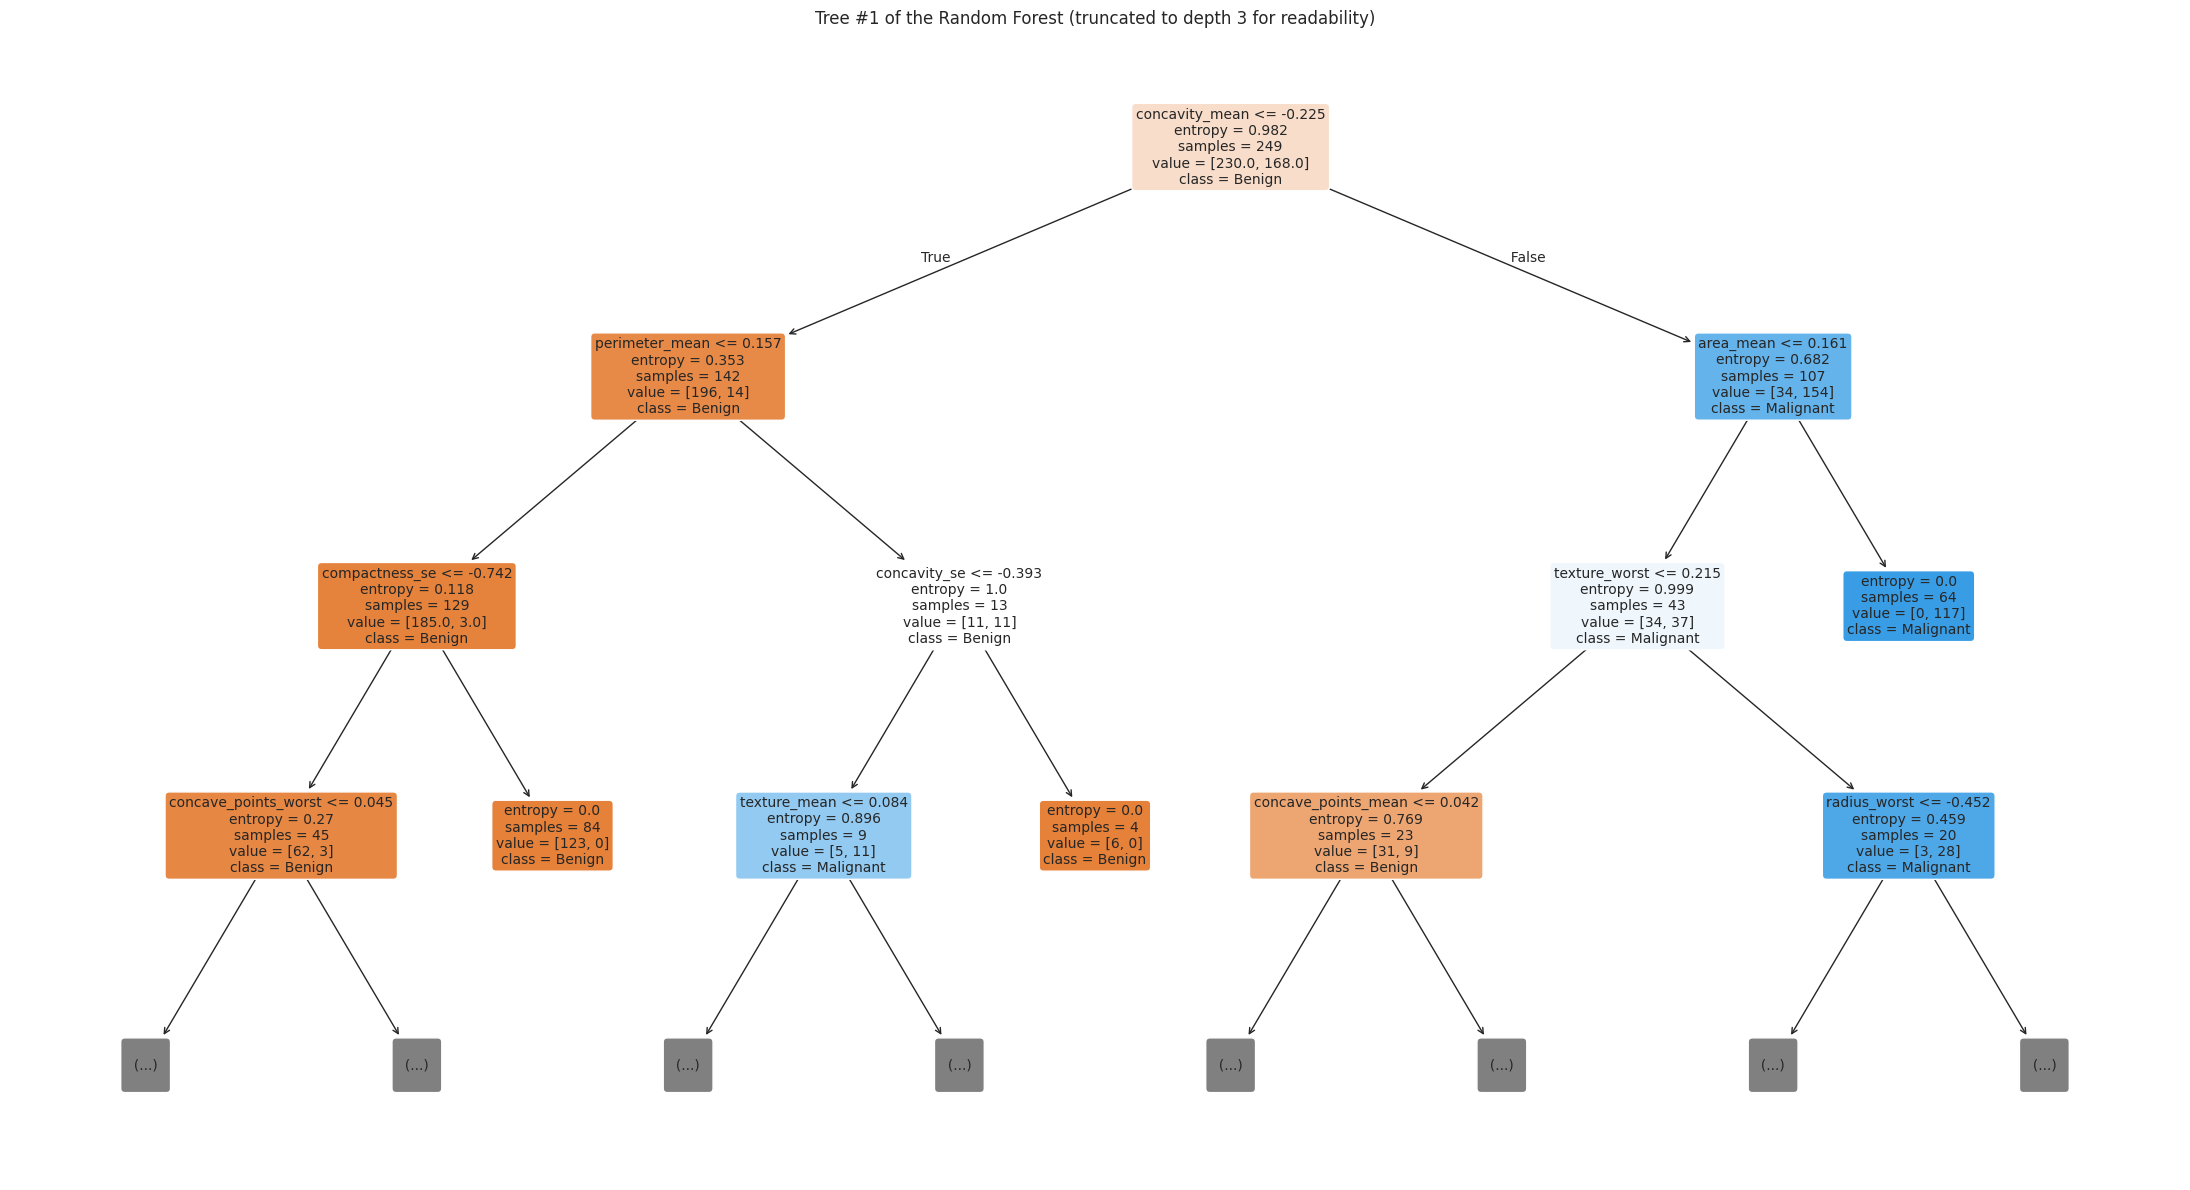

Tree depth: 7, leaves: 18


In [11]:
estimator = model.estimators_[0]

plt.figure(figsize=(22, 12))
plot_tree(estimator,
          feature_names=data.drop(columns=['id', 'diagnosis']).columns.tolist(),
          class_names=['Benign', 'Malignant'],
          filled=True, rounded=True,
          fontsize=10, max_depth=3)
plt.title('Tree #1 of the Random Forest (truncated to depth 3 for readability)')
plt.tight_layout()
plt.show()

print(f"Tree depth: {estimator.get_depth()}, leaves: {estimator.get_n_leaves()}")

## 11. Feature Importance

The mean Gini/entropy decrease across all 10 trees gives the **feature
importance**.  We plot the top-15 features.

,Feature,Importance
27,concave_points_worst,0.152979
7,concave_points_mean,0.140411
23,area_worst,0.117675
13,area_se,0.097530
6,concavity_mean,0.080392
3,area_mean,0.072993
10,radius_se,0.036482
20,radius_worst,0.036331
0,radius_mean,0.035123
22,perimeter_worst,0.029060


/tmp/ipykernel_4894/1342266383.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature',


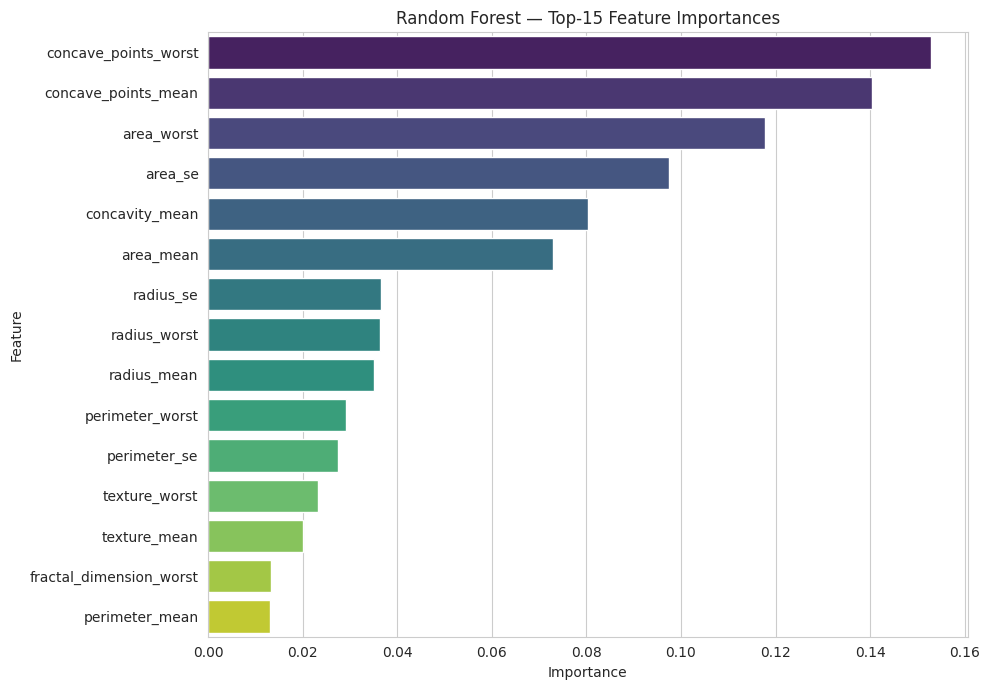

In [12]:
feat_names = data.drop(columns=['id', 'diagnosis']).columns.tolist()
importance = pd.DataFrame({
    'Feature'    : feat_names,
    'Importance' : model.feature_importances_,
}).sort_values('Importance', ascending=False)

display(importance.head(15))

plt.figure(figsize=(10, 7))
sns.barplot(x='Importance', y='Feature',
            data=importance.head(15), palette='viridis')
plt.title('Random Forest — Top-15 Feature Importances')
plt.tight_layout()
plt.show()

## 12. Compare Forest Sizes — Accuracy vs `n_estimators`

We sweep the number of trees from 1 to 100 and plot training and testing
accuracy.  More trees → lower variance → better generalisation (up to a
plateau).

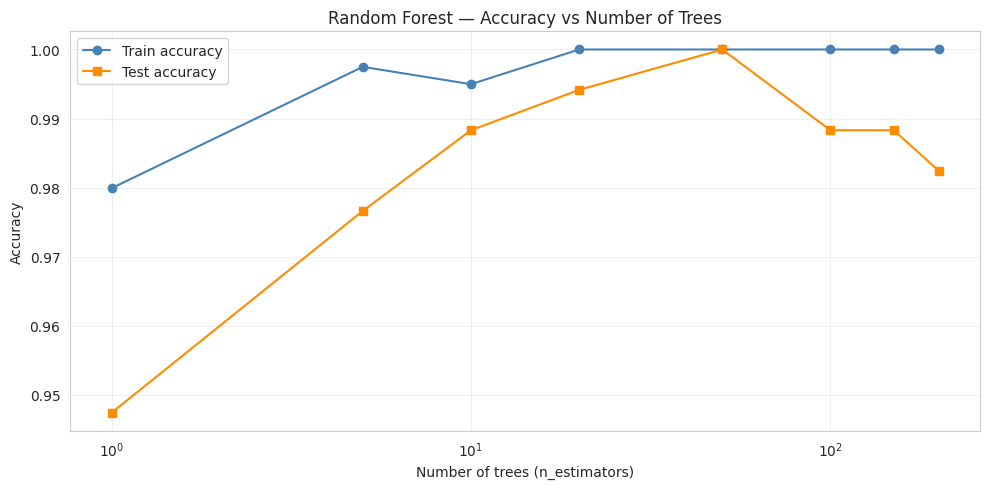

In [13]:
n_trees = [1, 5, 10, 20, 50, 100, 150, 200]
trains, tests = [], []
for n in n_trees:
    m = RandomForestClassifier(n_estimators=n, criterion='entropy',
                              random_state=0)
    m.fit(X_train_scaled, y_train)
    trains.append(m.score(X_train_scaled, y_train))
    tests.append(m.score(X_test_scaled, y_test))

plt.figure(figsize=(10, 5))
plt.plot(n_trees, trains, 'o-', label='Train accuracy', color='steelblue')
plt.plot(n_trees, tests,  's-', label='Test accuracy',  color='darkorange')
plt.xscale('log')
plt.xlabel('Number of trees (n_estimators)')
plt.ylabel('Accuracy')
plt.title('Random Forest — Accuracy vs Number of Trees')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 13. Out-of-Bag (OOB) Score

Each tree's bootstrap sample leaves out roughly 37% of the training rows;
those **out-of-bag** samples give an honest accuracy estimate without
needing a separate validation set.

In [14]:
model_oob = RandomForestClassifier(n_estimators=100, criterion='entropy',
                                  random_state=0, oob_score=True)
model_oob.fit(X_train_scaled, y_train)
print(f"OOB score (n_estimators=100): {model_oob.oob_score_:.4f}")
print(f"Test accuracy                : {model_oob.score(X_test_scaled, y_test):.4f}")

OOB score (n_estimators=100): 0.9523
Test accuracy                : 0.9883


## 📝 Exercises (Lab Book §12.6, page 58)

> Submit the Colab link or GitHub link or any `.ipynb` file for the exercises.

1. **Fruit basket ensemble.** Consider a fruit basket as the data shown in
   the Lab Book figure.  Take `n` random samples (with replacement) from the
   basket; build an individual decision tree on each sample.  Each tree
   produces a class prediction; the Random Forest then takes the majority
   vote.  Which fruit is most likely to be picked most often?  Build a small
   synthetic fruit dataset (features: colour, size, weight, sweetness) and
   apply this ensemble to it.


## 📚 Key Takeaways

- **Random Forest** is an ensemble of decision trees trained via bagging
  (bootstrap + random feature subspace).
- Each tree's prediction is combined by **majority vote** (classification)
  or **averaging** (regression).
- **Pros:** less prone to overfitting than a single decision tree, gives
  feature importance for free, robust to outliers, no scaling required.
- **Cons:** less interpretable than a single tree, more expensive to train
  and predict, can be biased toward the majority class on imbalanced data.
- **OOB score** gives an honest cross-validation estimate without holding
  out a separate validation set.


## 🔗 References

- Lab Activity Book (23CSE301), §12 Random Forests, page 53–58.
- Scikit-learn user guide — Random Forests:
  <https://scikit-learn.org/stable/modules/ensemble.html#forest>
- Breiman (2001), *Random Forests*, Machine Learning 45(1): 5–32.
